<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/DLinear/model_experiment_DLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLinear experiment v1 — longer context + series calibration

This is the first incremental experiment after `baseline_dlinear.ipynb`.

What changes from baseline:
- validation remains the last 39 weeks;
- metric remains Kaggle WMAE;
- DLinear remains the core model;
- input window increases from 52 to 104 weeks;
- a small Store-Dept series calibration layer is added;
- W&B logging is kept for comparison.

This is not the final DLinear notebook. Later we can add covariates, tuning, richer ablations, final pipeline, and inference.

In [1]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

In [2]:

from __future__ import annotations

import json
import math
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pd.set_option("display.max_columns", 100)
print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
})

{'python': '3.12.13', 'torch': '2.11.0+cpu', 'cuda_available': False, 'device_name': 'cpu'}


In [9]:
CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "input_weeks": 52,  # Reduced from 104 to allow for training windows
    "holiday_weight": 5.0,
    "batch_size": 512,
    "epochs": 80,
    "learning_rate": 8e-4,
    "weight_decay": 2e-4,
    "series_bias_weight_decay": 1e-3,
    "patience": 12,
    "num_workers": 2,
    "clip_grad_norm": 1.0,
    "moving_avg_kernel": 25,
    "use_series_calibration": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "dlinear-experiments",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/dlinear_experiment_v1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'input_weeks': 52,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'epochs': 80,
 'learning_rate': 0.0008,
 'weight_decay': 0.0002,
 'series_bias_weight_decay': 0.001,
 'patience': 12,
 'num_workers': 2,
 'clip_grad_norm': 1.0,
 'moving_avg_kernel': 25,
 'use_series_calibration': True,
 'device': 'cpu',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'dlinear-experiments'}

In [4]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")

Mounted at /content/drive


## Data preparation

Same split as the baseline: train on history before the last 39 weeks, validate on the last 39 weeks.

In [5]:
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing_train = required_train.difference(train_raw.columns)
missing_test = required_test.difference(test_raw.columns)
if missing_train or missing_test:
    raise ValueError({"missing_train": sorted(missing_train), "missing_test": sorted(missing_test)})

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]
split_pos = len(fit_dates)

if split_pos < CONFIG["input_weeks"]:
    raise ValueError("input_weeks is longer than available pre-validation history.")

sales_panel = (
    train_raw.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)

print({
    "n_series": len(sales_panel),
    "n_dates": len(all_train_dates),
    "fit_range": (str(fit_dates.min().date()), str(fit_dates.max().date())),
    "validation_range": (str(val_dates.min().date()), str(val_dates.max().date())),
    "test_horizon": len(test_dates),
})

{'n_series': 3331, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'test_horizon': 39}


In [6]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights))


class WindowDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, end_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.end_pos = int(end_pos)
        self.index = []
        max_start = self.end_pos - self.input_len - self.pred_len
        if max_start < 0:
            raise ValueError("Not enough history for configured windows.")
        for series_idx in range(self.values.shape[0]):
            for start in range(max_start + 1):
                self.index.append((series_idx, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx: int):
        series_idx, start = self.index[idx]
        x = self.values[series_idx, start:start + self.input_len]
        y = self.values[series_idx, start + self.input_len:start + self.input_len + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(start + self.input_len, start + self.input_len + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }


class ValidationDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, split_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.split_pos = int(split_pos)

    def __len__(self):
        return self.values.shape[0]

    def __getitem__(self, series_idx: int):
        start = self.split_pos - self.input_len
        x = self.values[series_idx, start:self.split_pos]
        y = self.values[series_idx, self.split_pos:self.split_pos + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(self.split_pos, self.split_pos + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }

In [7]:
class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.avg = nn.AvgPool1d(kernel_size=self.kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left
        front = x[:, :1, :].repeat(1, pad_left, 1)
        end = x[:, -1:, :].repeat(1, pad_right, 1)
        x_pad = torch.cat([front, x, end], dim=1)
        return self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_average = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_average(x)
        seasonal = x - trend
        return seasonal, trend


class DLinearWithSeriesCalibration(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, n_series: int, moving_avg_kernel: int = 25, use_series_calibration: bool = True):
        super().__init__()
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)
        self.use_series_calibration = bool(use_series_calibration)
        self.decomposition = SeriesDecomposition(moving_avg_kernel)
        self.linear_seasonal = nn.Linear(self.seq_len, self.pred_len)
        self.linear_trend = nn.Linear(self.seq_len, self.pred_len)
        if self.use_series_calibration:
            self.series_bias = nn.Embedding(n_series, self.pred_len)
        else:
            self.series_bias = None
        self._init_weights()

    def _init_weights(self):
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / self.seq_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / self.seq_len)
        nn.init.zeros_(self.linear_seasonal.bias)
        nn.init.zeros_(self.linear_trend.bias)
        if self.series_bias is not None:
            nn.init.zeros_(self.series_bias.weight)

    def forward(self, x: torch.Tensor, series_idx: torch.Tensor | None = None) -> torch.Tensor:
        seasonal, trend = self.decomposition(x)
        seasonal = seasonal.permute(0, 2, 1)
        trend = trend.permute(0, 2, 1)
        out = self.linear_seasonal(seasonal) + self.linear_trend(trend)
        out = out.permute(0, 2, 1).squeeze(-1)
        if self.series_bias is not None:
            if series_idx is None:
                raise ValueError("series_idx is required when series calibration is enabled.")
            out = out + self.series_bias(series_idx)
        return out


def weighted_mae_loss(pred: torch.Tensor, target: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (torch.abs(pred - target) * weights).sum() / weights.sum().clamp_min(1.0)

In [10]:
train_ds = WindowDataset(values, holiday_flags, CONFIG["input_weeks"], CONFIG["validation_weeks"], split_pos)
val_ds = ValidationDataset(values, holiday_flags, CONFIG["input_weeks"], CONFIG["validation_weeks"], split_pos)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

actual_val = values[:, split_pos:split_pos + CONFIG["validation_weeks"]]
# Use the last 52 weeks before split_pos for seasonal naive baseline
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG["validation_weeks"]]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG["validation_weeks"]], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "train_windows": len(train_ds),
    "validation_series": len(val_ds),
    "seasonal_naive_wmae": seasonal_naive_wmae,
})

{'train_windows': 46634, 'validation_series': 3331, 'seasonal_naive_wmae': 1604.2697073319134}


In [11]:
def evaluate_model(model: nn.Module, loader: DataLoader, device: str):
    model.eval()
    pred_batches, target_batches, weight_batches = [], [], []
    norm_loss_total = 0.0
    norm_weight_total = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            series_idx = batch["series_idx"].to(device)
            pred_norm = model(x, series_idx)
            norm_loss_total += float((torch.abs(pred_norm - y) * weights).sum().cpu())
            norm_weight_total += float(weights.sum().cpu())

            mean = batch["mean"].to(device).unsqueeze(1)
            std = batch["std"].to(device).unsqueeze(1)
            pred = (pred_norm * std + mean).clamp_min(0.0)
            target = y * std + mean

            pred_batches.append(pred.cpu().numpy())
            target_batches.append(target.cpu().numpy())
            weight_batches.append(batch["weights"].cpu().numpy())

    preds = np.concatenate(pred_batches, axis=0)
    targets = np.concatenate(target_batches, axis=0)
    weights = np.concatenate(weight_batches, axis=0)
    return {
        "preds": preds,
        "targets": targets,
        "weights": weights,
        "normalized_wmae": norm_loss_total / max(norm_weight_total, 1.0),
        "wmae": float(np.sum(np.abs(preds - targets) * weights) / np.sum(weights)),
    }

run = wandb.init(
    project=CONFIG["wandb_project"],
    entity=CONFIG["wandb_entity"],
    group=CONFIG["wandb_group"],
    job_type="experiment_train",
    name="dlinear_v1_52w_series_calibration",
    config=CONFIG,
)

wandb.config.update({
    "n_series": len(sales_panel),
    "train_windows": len(train_ds),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "baseline_dlinear_39w_wmae": 1523.209716796875,
    "seasonal_naive_wmae": seasonal_naive_wmae,
}, allow_val_change=True)

device = CONFIG["device"]
model = DLinearWithSeriesCalibration(
    seq_len=CONFIG["input_weeks"],
    pred_len=CONFIG["validation_weeks"],
    n_series=len(sales_panel),
    moving_avg_kernel=CONFIG["moving_avg_kernel"],
    use_series_calibration=CONFIG["use_series_calibration"],
).to(device)

main_params = []
bias_params = []
for name, param in model.named_parameters():
    if "series_bias" in name:
        bias_params.append(param)
    else:
        main_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": main_params, "weight_decay": CONFIG["weight_decay"]},
    {"params": bias_params, "weight_decay": CONFIG["series_bias_weight_decay"]},
], lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

best_wmae = math.inf
best_epoch = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    train_loss_total = 0.0
    train_weight_total = 0.0
    for batch in train_loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        weights = batch["weights"].to(device)
        series_idx = batch["series_idx"].to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(x, series_idx)
        loss = weighted_mae_loss(pred, y, weights)
        loss.backward()
        if CONFIG["clip_grad_norm"]:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad_norm"])
        optimizer.step()

        train_loss_total += float((torch.abs(pred.detach() - y) * weights).sum().cpu())
        train_weight_total += float(weights.sum().cpu())

    train_loss = train_loss_total / max(train_weight_total, 1.0)
    val_result = evaluate_model(model, val_loader, device)
    scheduler.step(val_result["wmae"])

    metrics = {
        "epoch": epoch,
        "train/normalized_wmae_loss": train_loss,
        "validation/normalized_wmae_loss": val_result["normalized_wmae"],
        "validation/wmae": val_result["wmae"],
        "validation/improvement_vs_seasonal_naive_pct": 100.0 * (seasonal_naive_wmae - val_result["wmae"]) / seasonal_naive_wmae,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    wandb.log(metrics)
    print(metrics)

    if val_result["wmae"] < best_wmae:
        best_wmae = val_result["wmae"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)
best_val_result = evaluate_model(model, val_loader, device)
wandb.summary["best_epoch"] = best_epoch
wandb.summary["best_validation_wmae"] = best_val_result["wmae"]
wandb.summary["seasonal_naive_wmae"] = seasonal_naive_wmae

print({"best_epoch": best_epoch, "best_validation_wmae": best_val_result["wmae"]})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train/normalized_wmae_loss': 2.491702704238466, 'validation/normalized_wmae_loss': 0.6992740975032257, 'validation/wmae': 1597.418701171875, 'validation/improvement_vs_seasonal_naive_pct': 0.42704827802504863, 'learning_rate': 0.0008}
{'epoch': 2, 'train/normalized_wmae_loss': 2.433659180304478, 'validation/normalized_wmae_loss': 0.6940240440582344, 'validation/wmae': 1569.3055419921875, 'validation/improvement_vs_seasonal_naive_pct': 2.1794443403083004, 'learning_rate': 0.0008}
{'epoch': 3, 'train/normalized_wmae_loss': 2.4135011195395077, 'validation/normalized_wmae_loss': 0.6895460174848458, 'validation/wmae': 1544.1951904296875, 'validation/improvement_vs_seasonal_naive_pct': 3.7446644181879374, 'learning_rate': 0.0008}
{'epoch': 4, 'train/normalized_wmae_loss': 2.3987138748844106, 'validation/normalized_wmae_loss': 0.6873348557254706, 'validation/wmae': 1531.5213623046875, 'validation/improvement_vs_seasonal_naive_pct': 4.5346704917974705, 'learning_rate': 0.0008}
{'

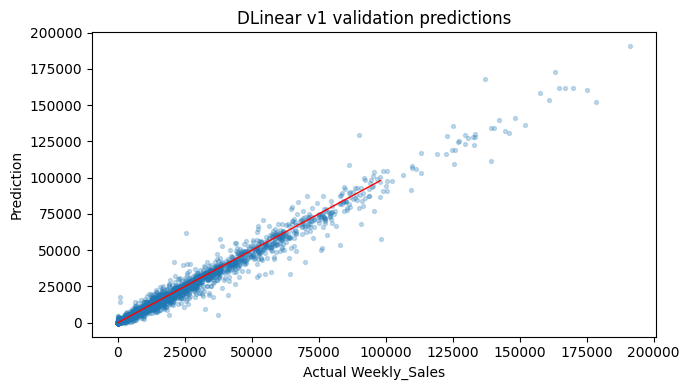

{'experiment': 'dlinear_v1_104w_series_calibration',
 'best_epoch': 11,
 'best_validation_wmae': 1506.282470703125,
 'baseline_dlinear_39w_wmae': 1523.209716796875,
 'seasonal_naive_wmae': 1604.2697073319134,
 'improvement_vs_baseline_pct': 1.111287953791809}

In [12]:
preds = best_val_result["preds"]
targets = best_val_result["targets"]

records = []
for row_idx, (store, dept) in enumerate(sales_panel.index):
    for horizon_idx, date in enumerate(val_dates):
        records.append({
            "Store": int(store),
            "Dept": int(dept),
            "Date": pd.Timestamp(date),
            "IsHoliday": bool(holiday_by_date.loc[date]),
            "Weekly_Sales": float(targets[row_idx, horizon_idx]),
            "Prediction": float(preds[row_idx, horizon_idx]),
            "AbsError": float(abs(targets[row_idx, horizon_idx] - preds[row_idx, horizon_idx])),
        })

val_pred_df = pd.DataFrame(records)
val_pred_path = OUTPUT_DIR / "dlinear_v1_validation_predictions.csv"
val_pred_df.to_csv(val_pred_path, index=False)

checkpoint_path = OUTPUT_DIR / "dlinear_v1_checkpoint.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "best_epoch": best_epoch,
    "best_validation_wmae": best_val_result["wmae"],
    "series_index": sales_panel.index.tolist(),
    "train_dates": [str(pd.Timestamp(d).date()) for d in all_train_dates],
    "validation_dates": [str(pd.Timestamp(d).date()) for d in val_dates],
}, checkpoint_path)

summary = {
    "experiment": "dlinear_v1_52w_series_calibration",
    "best_epoch": int(best_epoch),
    "best_validation_wmae": float(best_val_result["wmae"]),
    "baseline_dlinear_39w_wmae": 1523.209716796875,
    "seasonal_naive_wmae": float(seasonal_naive_wmae),
    "improvement_vs_baseline_pct": float(100.0 * (1523.209716796875 - best_val_result["wmae"]) / 1523.209716796875),
}
summary_path = OUTPUT_DIR / "dlinear_v1_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7, 4))
sample = val_pred_df.sample(min(5000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
ax.set_title("DLinear v1 validation predictions")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Prediction")
plt.tight_layout()
plot_path = OUTPUT_DIR / "dlinear_v1_validation_scatter.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact("dlinear-v1-52w-series-calibration", type="model")
artifact.add_file(str(checkpoint_path))
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(plot_path))
run.log_artifact(artifact, aliases=["experiment-v1", "latest"])

wandb.log({
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/scatter": wandb.Image(str(plot_path)),
})

summary

In [13]:
run.finish()

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
learning_rate,███████████████▃▃▃▃▃▁▁▁
train/normalized_wmae_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
validation/improvement_vs_seasonal_naive_pct,▁▃▅▆▆▇▇▇▇▇█▇█▇█▇▇▇▇▇▇▇▇
validation/normalized_wmae_loss,█▅▃▂▁▁▂▁▂▂▂▃▂▃▃▄▄▅▅▅▆▆▅
validation/wmae,█▆▄▃▃▂▂▂▂▂▁▂▁▂▁▂▂▂▂▂▂▂▂
best_epoch,11
best_validation_wmae,1506.28247
epoch,23
learning_rate,0.0002
seasonal_naive_wmae,1604.26971
